<a href="https://colab.research.google.com/github/elessardari/IDC-MaIE_2026A/blob/main/icd_taller4_estimacion_distribuciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **¡¡ ANTES DE EMPEZAR !!**

Deshabilita autocompletar con IA. Esta acción te ayudará a aprender de verdad. Si estás en Colab sigue estos pasos:



1.   Ir a Herramientas \ Configuración \ Asistencia de IA
2.   Desactivar la casilla **"Mostrar autocompletado impulsado por IA"**
3.   Activar la casilla **"Ocultar funciones de IA generativa"**


# **MÓDULO 1: OTRAS DISTRIBUCIONES TÍPICAS**
La distribución Normal y la Uniforme no son las únicas distribuciones de probabilidad típicas de variables aleatorias. En Ciencia de Datos, nos encontraremos con fenómenos que tienen comportamientos muy distintos que se modelan con otras distribuciones.

Por ejemplo, veamos estas tres distribuciones fundamentales:

1. **Distribución Exponencial:** Se usa en ingeniería de confiabilidad para modelar el tiempo hasta que una máquina falla, o en teoría de colas para modelar el tiempo de espera en la fila de un banco. El parámetro que identifica a la distribución exponencial es $\lambda$, el promedio de eventos (fallas o personas que llegan a la fila) por unidad de tiempo.

2. **Distribución Beta:** La distribución Beta es extremadamente flexible, siendo capaz de modelar distintos fenómenos dependiendo del valor de sus parámetros $\alpha$ y $\beta$. Por ejemplo, cuando $\alpha$ y $\beta$ son menores a 1 se puede usar para modelar la tasa de conversión de una campaña política donde los usuarios tienden a polarizarse.

3. **Distribución Log-Normal:** Se usa, por ejemplo, para modelar la distribución de la riqueza (pocas personas tienen muchísimo dinero), el tamaño de los archivos descargados de internet, o los precios de las acciones a largo plazo. Al igual que la distribución normal, sus parámetros son la media $\mu$ y la desviación estándar $\sigma$.

Veamos cómo son las Funciones de Densidad de Probabilidad (PDFs) de estas distribuciones a continuación.

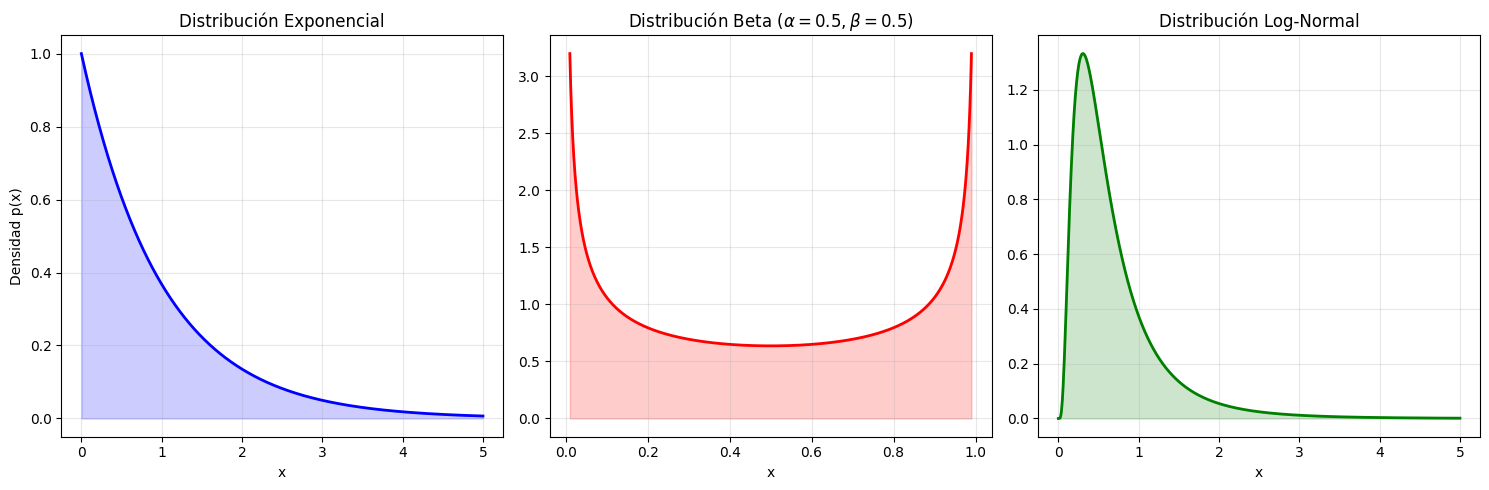

In [1]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, beta, lognorm

# Configuramos el tamaño de la figura
plt.figure(figsize=(15, 5))


# 1. GRÁFICA: DISTRIBUCIÓN EXPONENCIAL (lambda = 1)
# Parámetros:
l = 1 # lambda = 1
# Gráfica:
plt.subplot(1, 3, 1) # (1 fila, 3 columnas, gráfica 1)
x_expon = np.linspace(0, 5, 1000)
pdf_expon = expon.pdf(x_expon, scale=1/l) # scale = 1/lambda
plt.plot(x_expon, pdf_expon, 'b-', lw=2)
plt.fill_between(x_expon, pdf_expon, alpha=0.2, color='blue')
plt.title('Distribución Exponencial')
plt.ylabel('Densidad p(x)')
plt.xlabel('x')
plt.grid(True, alpha=0.3)


# 2. GRÁFICA: DISTRIBUCIÓN BETA (alpha = 0.5, beta = 0.5)
# Parámetros:
a = 0.5 # alpha = 0.5
b = 0.5 # beta = 0.5
# Gráfica
plt.subplot(1, 3, 2)
# Evitamos el 0 y 1 exactos porque la densidad tiende a infinito en los bordes para alpha<1, beta<1
x_beta = np.linspace(0.01, 0.99, 1000)
pdf_beta = beta.pdf(x_beta, a, b)
plt.plot(x_beta, pdf_beta, 'r-', lw=2)
plt.fill_between(x_beta, pdf_beta, alpha=0.2, color='red')
plt.title(r'Distribución Beta ($\alpha=0.5, \beta=0.5$)')
plt.xlabel('x')
plt.grid(True, alpha=0.3)


# 3. GRÁFICA: DISTRIBUCIÓN LOG-NORMAL (mu = 0.7 , sigma = 0.6)
# Parámetros:
mu = 0.7
sigma = 0.6
# Gráfica
plt.subplot(1, 3, 3)
x_lognorm = np.linspace(0, 5, 1000)
# En Python, la función log-normal tiene otros parámetros: s y scale.
# Estos parámetros se calculan a partir de mu y sigma así:
s_calculado =  np.sqrt(np.log(1 + (sigma**2 / mu**2)))
scale_calculado = mu / np.sqrt(1 + (sigma**2 / mu**2))
pdf_lognorm = lognorm.pdf(x_lognorm, s=s_calculado, scale=scale_calculado)
plt.plot(x_lognorm, pdf_lognorm, 'g-', lw=2)
plt.fill_between(x_lognorm, pdf_lognorm, alpha=0.2, color='green')
plt.title('Distribución Log-Normal')
plt.xlabel('x')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# **MÓDULO 2: MOMENTOS DE UNA VARIABLE ALEATORIA**

Si bien las gráficas de las PDFs nos dan la idea exacta de cómo se comporta una variable aleatoria (qué valores son los más probables, dónde está sesgada, etc.), a menudo no podemos o no queremos estar graficando cada variable.

En Ciencia de Datos, es conveniente resumir la gráfica en **características numéricas** que nos den una idea de la forma de la distribución sin necesidad de verla. Estos descriptores se conocen como **Momentos**.

Los momentos son, literalmente, la huella digital de una variable aleatoria. Si conoces todos los momentos de una variable, conoces exactamente su distribución.

### Fórmulas de los Momentos
Si conocemos la función de densidad $f_X(x)$, el $n$-ésimo Momento *Central* (*central* se refiere a que el cálculo se realiza respecto a la media $\mu$), denotado como $m_n$, se calcula integrando:
$$m_n = E[(X-\mu)^n] = \int_{-\infty}^{\infty} (x-\mu)^n \cdot f(x) dx$$

Pero si estamos trabajando empíricamente con **datos extraídos de una muestra** (tamaño $N$), estimamos los momentos así:
$$m_n = \frac{1}{N} \sum_{i=1}^{N} (x_i-\mu)^n$$

### Los 4 Momentos Principales
1. **Media / Valor Esperado (1er Momento):** Indica el "centro de masa" o tendencia central de la distribución.
2. **Varianza (2do Momento *Central*):** Mide qué tan esparcidos o dispersos están los valores alrededor de la media.
3. **Sesgo / Asimetría (3er Momento *Central*):** Indica hacia dónde está "inclinada" o sesgada la distribución. (0 es simétrica, positivo es cola hacia la derecha, negativo cola hacia la izquierda).
4. **Curtosis (4to Momento *Central*):** Mide el "peso" o grosor de las colas de la distribución en comparación con una distribución normal. Valores positivos y altos de curtosis significan que los eventos extremos (outliers) son más probables de lo que dictaría una campana de Gauss. Valores negativos indican una distribución más plana y con colas ligeras.

Cabe resaltar que el **Sesgo** y la **Curtosis** se suelen *''estandarizar''* para que no dependan de las unidades de la variable aleatoria (por ejemplo, para que sea comparable el sesgo obtenido con una distribución de peso en kilos con los de una distribución de alturas en metros de forma directa). La estandarización usa las siguientes fórmulas:

* **Sesgo Estandarizado**$\displaystyle\ =\frac{m_3}{\sigma^3}$
* **Curtosis Estandarizada**$\displaystyle\ =\frac{m_4}{\sigma^4}-3$:





In [2]:
# ==========================================
# --- INTUICIÓN VISUAL ---
# ==========================================

# ANTES de hacer cálculos, mira atentamente las 3 gráficas que generamos arriba.
# Usa tu intuición para responder las siguientes preguntas.
# Reemplaza el texto "[TU RESPUESTA AQUÍ]" con tu elección:
# Opciones válidas: 'Exponencial', 'Beta' o 'Log-Normal'

print("1. La distribución con mayor Media parece ser: Exponencial")
print("2. La distribución con mayor Varianza parece ser: Exponencial")
print("3. La distribución con mayor Asimetría (cola derecha más pesada) es: Log-Normal")
print("4. La distribución con mayor Curtosis (eventos extremos atípicos) es: Log-Normal")


1. La distribución con mayor Media parece ser: Exponencial
2. La distribución con mayor Varianza parece ser: Exponencial
3. La distribución con mayor Asimetría (cola derecha más pesada) es: Log-Normal
4. La distribución con mayor Curtosis (eventos extremos atípicos) es: Log-Normal


In [3]:
# ==========================================
# --- VERIFICACIÓN DE MOMENTOS CON PYTHON ---
# ==========================================
# Ahora, usemos Python para calcular los Momentos a partir de una
# simulación grande de datos. Así validaremos tus respuestas anteriores.

from scipy.stats import skew, kurtosis

N = 100000 # Tamaño de la muestra simulada

# 1. Generamos los datos aleatorios para cada distribución
datos_expon = expon.rvs(scale=1/l, size=N)
datos_beta = beta.rvs(a, b, size=N)
datos_lognorm = lognorm.rvs(s=s_calculado, scale=scale_calculado, size=N)

# Creamos un diccionario iterativo para calcular y mostrar todo en orden
distribuciones = {
    "Exponencial": datos_expon,
    "Beta": datos_beta,
    "Log-Normal": datos_lognorm
}

print("--- RESULTADOS DE LOS MOMENTOS EMPÍRICOS ---\n")

for nombre, datos in distribuciones.items():
    # Cálculo usando NumPy y SciPy
    m_media = np.mean(datos)
    m_varianza = np.var(datos)
    m_asimetria = skew(datos) # Calcula el sesgo estandarizado
    m_curtosis = kurtosis(datos) # Calcula la curtosis estandarizada

    skew

    print(f"Distribución {nombre}:")
    print(f"  - Media      (1er): {m_media:.4f}")
    print(f"  - Varianza   (2do): {m_varianza:.4f}")
    print(f"  - Sesgo      (3er): {m_asimetria:.4f}")
    print(f"  - Curtosis   (4to): {m_curtosis:.4f}\n")

# ¿Acertaste tus predicciones iniciales?


--- RESULTADOS DE LOS MOMENTOS EMPÍRICOS ---

Distribución Exponencial:
  - Media      (1er): 0.9957
  - Varianza   (2do): 0.9860
  - Sesgo      (3er): 1.9493
  - Curtosis   (4to): 5.4699

Distribución Beta:
  - Media      (1er): 0.5004
  - Varianza   (2do): 0.1244
  - Sesgo      (3er): -0.0025
  - Curtosis   (4to): -1.4964

Distribución Log-Normal:
  - Media      (1er): 0.7033
  - Varianza   (2do): 0.3695
  - Sesgo      (3er): 3.2112
  - Curtosis   (4to): 20.9123



# **Módulo 3: Estimación de una Distribución a partir de Datos**

En Ciencia de Datos, el proceso suele ser inverso al que acabamos de hacer: **no conocemos la distribución teórica de antemano**. Lo único que tenemos es una tabla con datos crudos y nuestro trabajo es descubrir qué distribución los generó.

### Proceso de Ajuste (Fitting)
1. **Obtener los datos y graficarlos:** Hacer un histograma para ver la forma.
2. **Calcular los Momentos:** Extraer la media, varianza, sesgo y curtosis de la muestra.
3. **Seleccionar Distribuciones Candidatas:** Usando la información de la gráfica y de los momentos calculados (ej. si el sesgo es muy positivo, descartamos la Normal y pensamos en una Exponencial o Log-Normal).
4. **Ajustar (Fit) los Parámetros:** Encontrar los parámetros que hacen que la curva teórica se adapte lo mejor posible a nuestro histograma.
5. Evaluar qué tan bien resulta el ajuste. Inicialmente, una inspección visual es útil. Luego, puede usarse una prueba de bondad como la **Prueba Kolmogorov-Smirnov (K-S)**. Esta calcula la distancia máxima entre la curva teórica y los datos reales. Cuanto más cercano a $0$ sea el estadístico K-S, mejor es el ajuste.

Vamos a aplicar este proceso a un **Dataset Real**. Analizaremos el total de las cuentas (`total_bill`) pagadas en un restaurante.

Primeras 5 cuentas registradas: [16.99 10.34 21.01 23.68 24.59]
Total de datos (N): 244

--- MOMENTOS EMPÍRICOS DE LAS CUENTAS ---
Media     : $19.79
Varianza  : 78.93
Sesgo     : 1.1262
Curtosis  : 1.1692


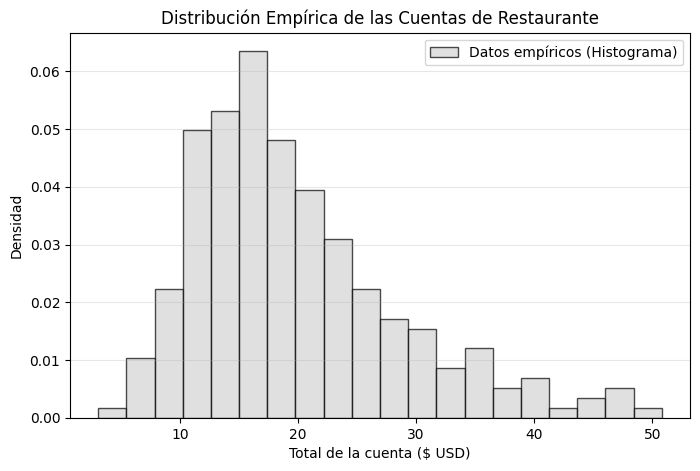

In [4]:
# Importamos seaborn que contiene datasets de prueba
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# 1. CARGAMOS EL DATASET REAL
# Este dataset contiene información sobre cuentas de restaurante y propinas
df_restaurante = sns.load_dataset('tips')

# Extraemos la variable que nos interesa: Total de la cuenta (en dólares)
datos_cuentas = df_restaurante['total_bill'].dropna().values

print("Primeras 5 cuentas registradas:", datos_cuentas[:5])
print("Total de datos (N):", len(datos_cuentas))

# ==========================================
# PASO 1 y 2: EXPLORACIÓN Y MOMENTOS
# ==========================================

# Calculamos los 4 momentos a partir de los datos
media = np.mean(datos_cuentas)
var = np.var(datos_cuentas)
sesgo = skew(datos_cuentas)
curtosis = kurtosis(datos_cuentas)

print("\n--- MOMENTOS EMPÍRICOS DE LAS CUENTAS ---")
print(f"Media     : ${media:.2f}")
print(f"Varianza  : {var:.2f}")
print(f"Sesgo     : {sesgo:.4f}")
print(f"Curtosis  : {curtosis:.4f}")

# Graficamos el histograma para ver la forma empírica
plt.figure(figsize=(8, 5))
# density=True hace que el área del histograma sume 1 (lo convierte en una Función de Densidad - PDF)
plt.hist(datos_cuentas, bins=20, density=True, color='lightgray', edgecolor='black', alpha=0.7, label='Datos empíricos (Histograma)')
plt.title('Distribución Empírica de las Cuentas de Restaurante')
plt.xlabel('Total de la cuenta ($ USD)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- PREGUNTA ---
# ¿Crees que una Distribución Normal clásica sería un buen modelo predictivo aquí? ¿por qué?


**Respuesta a la pregunta anterior:** 
No, una distribución Normal clásica NO es un buen modelo predictivo para este caso. Hay dos razones teóricas y prácticas fundamentales:
1. **Asimetría (Sesgo Positivo):** La distribución Normal asume simetría perfecta alrededor de la media (sesgo = 0). Sin embargo, vemos que el sesgo empírico es muy alto ($>1.1$). Esto ocurre porque la mayoría de las cuentas son estándar, pero ocasionalmente algunas mesas gastan muchísimo (ej. comprando vinos caros), creando una larga cola hacia la derecha que la Normal ignoraría o subestimaría.
2. **Límites Físicos Imposibles:** El total de una cuenta de restaurante no puede ser menor a $0. La distribución Normal se extiende matemáticamente desde infinito negativo a infinito positivo. Si ajustamos una Normal, el modelo predeciría que existe una probabilidad de que un cliente reciba una cuenta de $-5 USD, lo cual no tiene sentido en el mundo real.

### Evaluación de Candidatos: Normal vs. Log-Normal

Al analizar los momentos, notamos un **sesgo positivo fuerte ($>1$)**. Esto nos indica una cola pesada hacia la derecha (dado, por ejemplo, a que algunos clientes piden botellas de vino caras que inflan la cuenta).

En Python, la librería `scipy.stats` tiene un método llamado `.fit()`. Este método toma los datos empíricos y, utilizando técnicas de optimización (como el *Método de Máxima Verosimilitud*), calcula automáticamente cuáles deberían ser los parámetros de la curva para ajustarse "lo mejor posible" al histograma empírico.

Vamos a enfrentar a dos modelos candidatos:
1. La Distribución Normal.
2. La Distribución Log-Normal.

*¿A qué modelo le apuestas?*

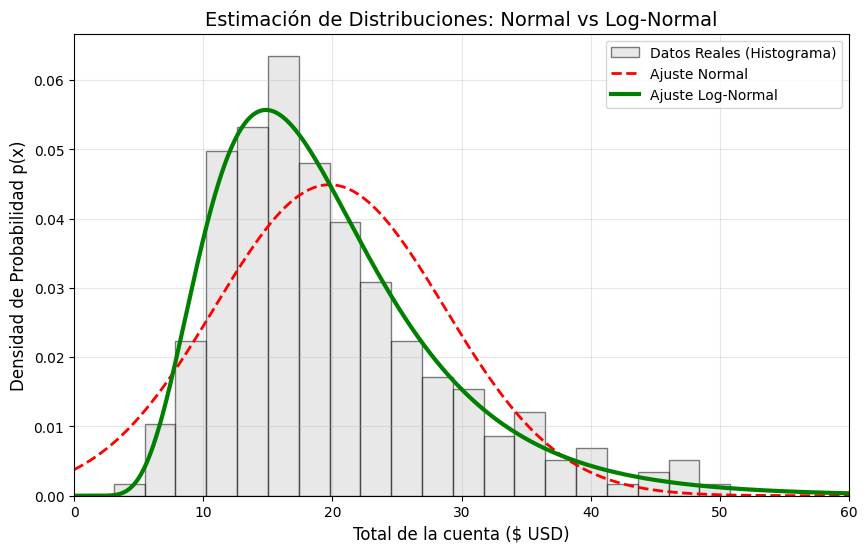


--- PRUEBA DE BONDAD DE AJUSTE (KOLMOGOROV-SMIRNOV) ---
Modelo Normal     -> Distancia K-S: 0.1188
Modelo Log-Normal -> Distancia K-S: 0.0358

--- CONCLUSIÓN ---
Visualmente notamos que la curva roja (Normal) abarca valores negativos imposibles y falla en la cola, subestimando la cantidad de cuentas caras.
Además, la distancia K-S de la Log-Normal es MENOR que la de la Normal.
Por lo tanto, la Log-Normal es matemáticamente un mejor modelo para estos datos.

>>> RESPUESTA: La probabilidad de que una cuenta esté entre $30 y $40 es de 0.0876 (es decir, un 8.76%)


In [5]:
from scipy.stats import norm, lognorm

# ==========================================
# PASO 3 y 4: AJUSTE (FIT) DE DISTRIBUCIONES
# ==========================================

# 1. Ajustamos la Distribución Normal
# .fit() devuelve los parámetros estimados: (media_estimada, desviacion_estimada)
parametros_normal = norm.fit(datos_cuentas)
media_norm, std_norm = parametros_normal

# 2. Ajustamos la Distribución Log-Normal
# .fit() devuelve: (forma 's', ubicacion 'loc', escala 'scale')
parametros_lognorm = lognorm.fit(datos_cuentas, floc=0) # Fijamos floc=0 porque las cuentas empiezan en $0
s_estimado, loc_estimado, scale_estimado = parametros_lognorm

# ==========================================
# PASO 5: VERIFICACIÓN VISUAL
# ==========================================

# Creamos un eje X continuo para trazar nuestras curvas teóricas (desde $0 hasta $60)
x_teorico = np.linspace(0, 60, 1000)

# Generamos los valores Y (las PDFs) usando los parámetros que acabamos de encontrar
pdf_normal = norm.pdf(x_teorico, loc=media_norm, scale=std_norm)
pdf_lognorm = lognorm.pdf(x_teorico, s=s_estimado, loc=loc_estimado, scale=scale_estimado)

# Graficamos todo
plt.figure(figsize=(10, 6))

# 1. El histograma real
plt.hist(datos_cuentas, bins=20, density=True, color='lightgray', edgecolor='black', alpha=0.5, label='Datos Reales (Histograma)')

# 2. La curva Normal
plt.plot(x_teorico, pdf_normal, 'r--', lw=2, label='Ajuste Normal')

# 3. La curva Log-Normal
plt.plot(x_teorico, pdf_lognorm, 'g-', lw=3, label='Ajuste Log-Normal')

plt.title('Estimación de Distribuciones: Normal vs Log-Normal', fontsize=14)
plt.xlabel('Total de la cuenta ($ USD)', fontsize=12)
plt.ylabel('Densidad de Probabilidad p(x)', fontsize=12)
plt.legend()
plt.grid(axis='both', alpha=0.3)

# Limitamos el eje X para que se vea igual que el histograma
plt.xlim(0, 60)
plt.show()

# ==========================================
# PASO 6: VERIFICACIÓN CUANTITATIVA (K-S TEST)
# ==========================================
from scipy.stats import kstest

print("\n--- PRUEBA DE BONDAD DE AJUSTE (KOLMOGOROV-SMIRNOV) ---")
# Probamos qué tan bien se ajusta la Normal
stat_norm, p_norm = kstest(datos_cuentas, 'norm', args=(media_norm, std_norm))
# Probamos qué tan bien se ajusta la Log-Normal
stat_lognorm, p_lognorm = kstest(datos_cuentas, 'lognorm', args=(s_estimado, loc_estimado, scale_estimado))

print(f"Modelo Normal     -> Distancia K-S: {stat_norm:.4f}")
print(f"Modelo Log-Normal -> Distancia K-S: {stat_lognorm:.4f}")

print("\n--- CONCLUSIÓN ---")
print("Visualmente notamos que la curva roja (Normal) abarca valores negativos imposibles y falla en la cola, subestimando la cantidad de cuentas caras.")
print("Además, la distancia K-S de la Log-Normal es MENOR que la de la Normal.")
print("Por lo tanto, la Log-Normal es matemáticamente un mejor modelo para estos datos.")

# ==========================================
# PREGUNTA: Cuál es la probabilidad de que la cuenta salga por entre $30 y $40 USD?
# - Aquí tu código que soluciona esta pregunta: -


prob_hasta_40 = lognorm.cdf(40, s=s_estimado, loc=loc_estimado, scale=scale_estimado)
prob_hasta_30 = lognorm.cdf(30, s=s_estimado, loc=loc_estimado, scale=scale_estimado)

prob_rango = prob_hasta_40 - prob_hasta_30

print(f"\n>>> RESPUESTA: La probabilidad de que una cuenta esté entre $30 y $40 es de {prob_rango:.4f} (es decir, un {prob_rango*100:.2f}%)")


# **Reto 1: Toma de Decisiones Financieras bajo Incertidumbre**

Hasta ahora hemos analizado variables aleatorias por separado. Sin embargo, en la vida real, los fenómenos interactúan entre sí.

### Contexto del Negocio
Una *Startup* de Inteligencia Artificial tiene un modelo de negocio que cobra una tarifa a los clientes por usar su API. A la vez, le cuesta dinero procesar esas peticiones en servidores de Amazon Web Services (AWS).

Se tienen dos variables aleatorias diarias:
1. **Los Ingresos Diarios ($I$):** Son muy estables y predecibles. Siguen una **Distribución Normal** con media $\mu = \$5.000$ y desviación estándar $\sigma = \$500$.
2. **Los Costos Diarios de AWS ($C$):** Dependen de picos de computación (por ejemplo, clientes subiendo archivos muy grandes). Siguen una **Distribución Log-Normal** fuertemente sesgada a la derecha. La mayoría de los días el costo es bajo, pero de vez en cuando hay picos muy altos. La media de la distribución es $\mu = \$3.830 $ y su desviación estándar es $\sigma = \$3.050 $.

El equipo financiero debe tomar una decisión entre estas opciones:

* **Opción A (Plan Variable):** Seguir pagando a AWS como se ha venido haciendo. Es decir, los costos se modelan a través de la **Log-Normal** descrita anteriormente.
* **Opción B (Plan Tarifa Plana):** AWS ofrece un seguro. Un pago fijo garantizado de **$\$4,200$** diarios. Tráfico ilimitado.

**Entregable:** Calcular mediante simulación (100000 días) la **Ganancia Diaria ($G = I - C$)** para ambas opciones y decidir cuál plan minimiza el riesgo de que la empresa pierda dinero en un día determinado ($G < 0$).

--- RESULTADOS PLAN A (Variable) ---
Ganancia Media Esperada : $1171.94
Probabilidad de Pérdida (G < 0): 23.69%

--- RESULTADOS PLAN B (Tarifa Plana) ---
Ganancia Media Esperada : $800.48
Probabilidad de Pérdida (G < 0): 5.44%

CONCLUSIÓN AWS:
Aunque el Plan A tiene una ganancia media ligeramente superior, su riesgo operativo (probabilidad de perder dinero un día) es masivo (~25%).
El Plan B reduce el riesgo a menos de un 6%, lo cual es mucho más seguro para la liquidez de la Startup. ¡Deberían elegir el Plan B!


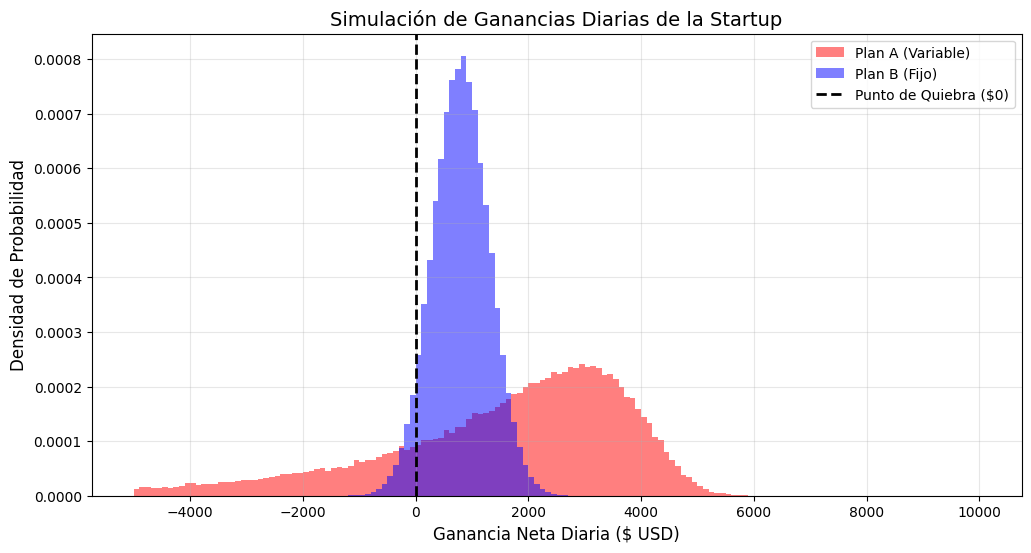

In [6]:
# --- CÓDIGO PROBLEMA AWS ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm


N_dias = 100000
np.random.seed(42) # Semilla para reproducibilidad


mu_I = 5000
sigma_I = 500
ingresos = norm.rvs(loc=mu_I, scale=sigma_I, size=N_dias)


mu_C = 3830
sigma_C = 3050

s_aws = np.sqrt(np.log(1 + (sigma_C**2 / mu_C**2)))
scale_aws = mu_C / np.sqrt(1 + (sigma_C**2 / mu_C**2))
costos_variables = lognorm.rvs(s=s_aws, scale=scale_aws, size=N_dias)


ganancia_plan_A = ingresos - costos_variables
ganancia_plan_B = ingresos - 4200 # Costo fijo de AWS


print("--- RESULTADOS PLAN A (Variable) ---")
print(f"Ganancia Media Esperada : ${np.mean(ganancia_plan_A):.2f}")
print(f"Probabilidad de Pérdida (G < 0): {np.mean(ganancia_plan_A < 0):.2%}\n")

print("--- RESULTADOS PLAN B (Tarifa Plana) ---")
print(f"Ganancia Media Esperada : ${np.mean(ganancia_plan_B):.2f}")
print(f"Probabilidad de Pérdida (G < 0): {np.mean(ganancia_plan_B < 0):.2%}\n")

print("CONCLUSIÓN AWS:")
print("Aunque el Plan A tiene una ganancia media ligeramente superior, su riesgo operativo (probabilidad de perder dinero un día) es masivo (~25%).")
print("El Plan B reduce el riesgo a menos de un 6%, lo cual es mucho más seguro para la liquidez de la Startup. ¡Deberían elegir el Plan B!")


plt.figure(figsize=(12, 6))
plt.hist(ganancia_plan_A, bins=150, range=(-5000, 10000), alpha=0.5, label='Plan A (Variable)', density=True, color='red')
plt.hist(ganancia_plan_B, bins=150, range=(-5000, 10000), alpha=0.5, label='Plan B (Fijo)', density=True, color='blue')
plt.axvline(0, color='black', linestyle='dashed', linewidth=2, label='Punto de Quiebra ($0)')
plt.title('Simulación de Ganancias Diarias de la Startup', fontsize=14)
plt.xlabel('Ganancia Neta Diaria ($ USD)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# **Reto 2: Decisiones Basadas en Datos**

Cuando tenemos suficientes datos reales, a menudo los usamos directamente para simular escenarios futuros. Esta técnica se llama **Bootstrapping** (muestreo con reemplazo).

### Contexto del Negocio

Un restaurante está considerando reformar su política salarial para los meseros. Sabemos que en un turno típico nocturno, **un mesero atiende exactamente a 20 mesas**.

Para este análisis, intervendrán **dos variables aleatorias** de nuestro dataset sobre las cuentas de un restaurante: el total de la cuenta (`total_bill`) y la propina dejada (`tip`).

* **Opción A (Modelo Tradicional):** El mesero gana *exclusivamente* las propinas dejadas por los clientes.

* **Opción B (Modelo "Servicio Incluido"):** Se prohíben las propinas. A cambio, el restaurante garantiza al mesero un **16% fijo** sobre el monto total de cada cuenta que atienda.

**Entregable:** Simular 100.000 turnos de trabajo usando los datos reales para responder: ¿Qué modelo tiene una mayor ganancia esperada? Y lo más importante para la estabilidad del empleado: ¿Cuál modelo tiene menor **riesgo** de que un mesero termine su turno con menos de $60 dólares en el bolsillo?

--- RETO 2: Modelo Tradicional vs Servicio Incluido (16%) ---

Opción A (solo propinas):
  Ganancia esperada por turno: $59.98
  Riesgo P(ganancia < $60):   0.5228 (52.28%)

Opción B (16% fijo sobre cuenta):
  Ganancia esperada por turno: $63.31
  Riesgo P(ganancia < $60):   0.3126 (31.26%)

--- RESPUESTAS ---
Mayor ganancia esperada: Opción B ($63.31)
Menor riesgo (<$60):    Opción B (riesgo 31.26%)


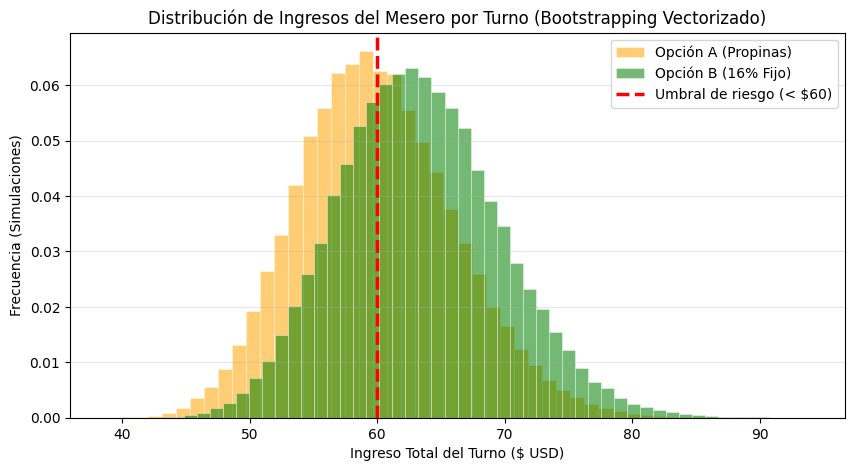

In [7]:
# --- CÓDIGO PROBLEMA RESTAURANTE ---
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


df = sns.load_dataset('tips').dropna()

datos_mesas = df[['total_bill', 'tip']].values

n_turnos = 100000
mesas_por_turno = 20
np.random.seed(42)


indices_simulados = np.random.choice(len(datos_mesas), size=(n_turnos, mesas_por_turno), replace=True)


sim_cuentas = datos_mesas[indices_simulados, 0] # Columna 0 es total_bill
sim_propinas = datos_mesas[indices_simulados, 1] # Columna 1 es tip


ganancia_A = np.sum(sim_propinas, axis=1)
ganancia_B = np.sum(sim_cuentas * 0.16, axis=1)

media_A, media_B = np.mean(ganancia_A), np.mean(ganancia_B)
riesgo_A = np.mean(ganancia_A < 60)  # P(ganancia < $60)
riesgo_B = np.mean(ganancia_B < 60)


print("--- RETO 2: Modelo Tradicional vs Servicio Incluido (16%) ---\n")
print("Opción A (solo propinas):")
print(f"  Ganancia esperada por turno: ${media_A:.2f}")
print(f"  Riesgo P(ganancia < $60):   {riesgo_A:.4f} ({riesgo_A*100:.2f}%)")

print("\nOpción B (16% fijo sobre cuenta):")
print(f"  Ganancia esperada por turno: ${media_B:.2f}")
print(f"  Riesgo P(ganancia < $60):   {riesgo_B:.4f} ({riesgo_B*100:.2f}%)")

print("\n--- RESPUESTAS ---")
print(f"Mayor ganancia esperada: Opción {'A' if media_A > media_B else 'B'} (${max(media_A, media_B):.2f})")
print(f"Menor riesgo (<$60):    Opción {'A' if riesgo_A < riesgo_B else 'B'} (riesgo {min(riesgo_A, riesgo_B)*100:.2f}%)")


plt.figure(figsize=(10, 5))
plt.hist(ganancia_A, bins=50, alpha=0.55, label='Opción A (Propinas)', color='orange', density=True, edgecolor='white', linewidth=0.5)
plt.hist(ganancia_B, bins=50, alpha=0.55, label='Opción B (16% Fijo)', color='green', density=True, edgecolor='white', linewidth=0.5)
plt.axvline(60, color='red', linestyle='--', linewidth=2.5, label='Umbral de riesgo (< $60)', zorder=5)
plt.title('Distribución de Ingresos del Mesero por Turno')
plt.xlabel('Ingreso Total del Turno ($ USD)')
plt.ylabel('Frecuencia (Simulaciones)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()
